# Machine Learning Model Implementation

This section implements a baseline predictive model and a neural network model for the House Prices dataset. Because the target variable, SalePrice, is numerical, this is a regression task. Therefore, the models will be evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared.

Although Kaggle provides a separate test dataset, that file does not contain SalePrice. Therefore, this project uses the Kaggle training dataset and splits it into new training and testing subsets so model performance can be evaluated using known sale prices.

In [1]:
# Import libraries for model development and evaluation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from IPython.display import display, Markdown
import pandas as pd
from datetime import datetime

todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "Jerbra1624"

## Prepare the Modeling Dataset

The modeling dataset is based on the original training dataset because it includes the target variable, SalePrice. Several engineered features are included to support the analytical tasks, including HomeAgeAtSale, YearsSinceRemodel, IsRemodeled, HasGarage, and HasBasement.

Missing values are handled based on the meaning of each variable. Many missing categorical values represent the absence of a housing feature, so they are filled with "None." Numerical absence-based values, such as MasVnrArea, are filled with 0. LotFrontage is treated as a true missing measurement and is filled using the median LotFrontage within each neighborhood.

In [2]:
# Load the dataset
data = pd.read_csv('/Users/jaybee718/Desktop/SDC486-Data Analytics-Lab/house-prices-advanced-regression-techniques/train.csv')

# Create engineered features related to age and renovations
data["HomeAgeAtSale"] = data["YrSold"] - data["YearBuilt"]
data["YearsSinceRemodel"] = data["YrSold"] - data["YearRemodAdd"]

data["IsRemodeled"] = np.where(
    data["YearBuilt"] != data["YearRemodAdd"],
    "Remodeled",
    "Not Remodeled"
)

# Create garage and basement indicators
data["HasGarage"] = np.where(data["GarageType"].isnull(), "No Garage", "Has Garage")
data["HasBasement"] = np.where(data["BsmtQual"].isnull(), "No Basement", "Has Basement")

# Review shape
print("Dataset shape:", data.shape)

Dataset shape: (1460, 86)


In [3]:
# Fill categorical missing values where missing means the feature is absent

none_fill_columns = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtFinType1", "BsmtFinType2", "BsmtExposure", "BsmtCond", "BsmtQual",
    "MasVnrType"
]

for column in none_fill_columns:
    if column in data.columns:
        data[column] = data[column].fillna("None")

# Fill numerical missing values where missing likely means absence of feature
if "MasVnrArea" in data.columns:
    data["MasVnrArea"] = data["MasVnrArea"].fillna(0)

# GarageYrBlt is missing when there is no garage.
# Instead of using median year, create GarageAgeAtSale and use 0 for no garage.
data["GarageAgeAtSale"] = data["YrSold"] - data["GarageYrBlt"]
data["GarageAgeAtSale"] = data["GarageAgeAtSale"].fillna(0)

# LotFrontage is a true missing measurement, so use neighborhood median.
data["LotFrontage"] = data.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

# If any LotFrontage values remain missing, fill with overall median as a backup.
data["LotFrontage"] = data["LotFrontage"].fillna(data["LotFrontage"].median())

# Electrical has only one missing value, so fill with the most common category.
data["Electrical"] = data["Electrical"].fillna(data["Electrical"].mode()[0])

# Confirm remaining missing values
remaining_missing = data.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)

print("Remaining missing values: remaining missing values in the full dataset do not affect modeling because GarageYrBlt was replaced by GarageAgeAtSale")
display(remaining_missing)

Remaining missing values: remaining missing values in the full dataset do not affect modeling because GarageYrBlt was replaced by GarageAgeAtSale


GarageYrBlt    81
dtype: int64

## Select Features and Target Variable

The target variable is SalePrice. The selected features include variables related to the project’s analytical issues: location, outliers, home age, renovations, and other important housing characteristics identified during EDA.

In [4]:
# Select features related to the analytical problems and EDA findings

selected_features = [
    # Location features
    "Neighborhood", "Condition1", "Condition2",
    
    # Strong numerical predictors from EDA
    "OverallQual", "GrLivArea", "GarageArea", "TotalBsmtSF", "FullBath",
    
    # Outlier-related features
    "LotArea",
    
    # Age and renovation features
    "YearBuilt", "YearRemodAdd", "HomeAgeAtSale", "YearsSinceRemodel",
    "IsRemodeled",
    
    # Additional relevant property features
    "LotFrontage", "MasVnrArea", "GarageAgeAtSale", "HasGarage", "HasBasement",
    "BsmtQual", "GarageType", "FireplaceQu", "Fence", "PoolQC"
]

# Keep only columns that exist in the dataset
selected_features = [col for col in selected_features if col in data.columns]

# Separate features and target
X = data[selected_features]
y = data["SalePrice"]

print("Selected feature count:", len(selected_features))
print("Selected features:")
print(selected_features)

print("\nFeature dataset shape:", X.shape)
print("Target shape:", y.shape)

Selected feature count: 24
Selected features:
['Neighborhood', 'Condition1', 'Condition2', 'OverallQual', 'GrLivArea', 'GarageArea', 'TotalBsmtSF', 'FullBath', 'LotArea', 'YearBuilt', 'YearRemodAdd', 'HomeAgeAtSale', 'YearsSinceRemodel', 'IsRemodeled', 'LotFrontage', 'MasVnrArea', 'GarageAgeAtSale', 'HasGarage', 'HasBasement', 'BsmtQual', 'GarageType', 'FireplaceQu', 'Fence', 'PoolQC']

Feature dataset shape: (1460, 24)
Target shape: (1460,)


## Train/Test Split

The Kaggle training dataset is split into training and testing subsets. This allows the models to be trained on one portion of the data and evaluated on another portion that still contains known SalePrice values.

In [5]:
# Log-transform SalePrice to reduce skewness and improve model stability
y_log = np.log1p(y)

# Split into training and testing subsets
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train_log.shape)
print("y_test shape:", y_test_log.shape)

X_train shape: (1168, 24)
X_test shape: (292, 24)
y_train shape: (1168,)
y_test shape: (292,)


## Preprocess Features for Modeling

Numerical features are standardized so that they are on a similar scale. Categorical features are one-hot encoded so they can be used by the linear regression model and neural network. The preprocessing transformer is fitted only on the training data and then applied to both the training and testing data.

In [6]:
# Identify numerical and categorical features
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical features:", numeric_features)
print("\nCategorical features:", categorical_features)

# Handle OneHotEncoder parameter differences between scikit-learn versions
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

# Create preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", onehot, categorical_features)
    ]
)

# Fit on training data and transform both training and testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Numerical features: ['OverallQual', 'GrLivArea', 'GarageArea', 'TotalBsmtSF', 'FullBath', 'LotArea', 'YearBuilt', 'YearRemodAdd', 'HomeAgeAtSale', 'YearsSinceRemodel', 'LotFrontage', 'MasVnrArea', 'GarageAgeAtSale']

Categorical features: ['Neighborhood', 'Condition1', 'Condition2', 'IsRemodeled', 'HasGarage', 'HasBasement', 'BsmtQual', 'GarageType', 'FireplaceQu', 'Fence', 'PoolQC']
Processed X_train shape: (1168, 88)
Processed X_test shape: (292, 88)


/var/folders/wr/hzrgtmnd1s165mw9hks13hp40000gn/T/ipykernel_98159/520330929.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()


## Baseline Predictive Model: Linear Regression

A linear regression model is used as the baseline predictive model. This model provides a simple comparison point before implementing the neural network. Since SalePrice is a continuous numerical variable, regression metrics are used instead of classification metrics.

In [7]:
# Build and train the baseline linear regression model
baseline_model = LinearRegression()

baseline_model.fit(X_train_processed, y_train_log)

# Make predictions on the test set
baseline_predictions_log = baseline_model.predict(X_test_processed)

print("Baseline model training complete.")

Baseline model training complete.


In [8]:
display(Markdown("### Baseline Predictive Model: Linear Regression"))
display(Markdown(f"Date: {todays_date}")) 
display(Markdown(f"Student ID: {student_id}"))

# Function to evaluate regression models
# Predictions are converted back from log scale to dollar scale for easier interpretation.

def evaluate_regression_model(y_true_log, y_pred_log, model_name):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    
    # Prevent negative dollar predictions
    y_pred = np.maximum(y_pred, 0)
    
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    return pd.DataFrame({
        "Model": [model_name],
        "MAE": [mae],
        "MSE": [mse],
        "RMSE": [rmse],
        "R-squared": [r2]
    })

baseline_results = evaluate_regression_model(
    y_test_log,
    baseline_predictions_log,
    "Baseline Linear Regression"
)

display(baseline_results)

### Baseline Predictive Model: Linear Regression

Date: 2026-06-13

Student ID: Jerbra1624

,Model,MAE,MSE,RMSE,R-squared
0,Baseline Linear Regression,18608.596745,8.744248e+08,29570.674044,0.885999


## Baseline Model Interpretation

The baseline predictive model used Linear Regression to predict home sale prices. Since SalePrice is a continuous numerical variable, this is a regression problem. Therefore, the model was evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared instead of classification metrics such as accuracy, precision, recall, or F1-score.

The baseline Linear Regression model produced a Mean Absolute Error (MAE) of approximately 18,609 dollars. This means that, on average, the model’s predicted home prices were about 18,609 away from the actual sale prices. In the context of housing prices, this is a reasonable starting point because home values can vary widely based on location, size, condition, age, and other property features.

The model also produced a Root Mean Squared Error (RMSE) of approximately 29,571 dollars. The RMSE is higher than the MAE because it gives more weight to larger prediction errors. This suggests that while many predictions may be fairly close, the model likely made larger errors on some homes. These larger errors may be connected to outliers, unusual properties, or homes with combinations of features that are harder for a linear model to capture.

The model’s R-squared value was approximately 0.886, meaning that the selected features explained about 88.6% of the variation in SalePrice. This indicates that the baseline model performed fairly well and that the selected features have a strong relationship with home sale prices. Features such as overall quality, living area, garage area, basement size, location, home age, and renovation history likely contributed to the model’s predictive strength.

Overall, the baseline Linear Regression model provides a strong starting point for comparison. However, because Linear Regression assumes mostly linear relationships, it may not fully capture more complex patterns in the housing data. The neural network model will be used next to determine whether a more flexible model can improve prediction performance by learning nonlinear relationships between the housing features and SalePrice.

In [9]:
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Define the neural network architecture
nn_model = Sequential([
    Input(shape=(X_train_processed.shape[1],)),
    
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    
    Dense(1)
])

# Compile the model
nn_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="mse",
    metrics=["mae"]
)

# Display model summary
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         5,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,809 (30.50 KB)

 Trainable params: 7,809 (30.50 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Stop training early if validation loss stops improving
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

# Train the neural network
history = nn_model.fit(
    X_train_processed,
    y_train_log,
    validation_data=(X_test_processed, y_test_log),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 116.5664 - mae: 10.7670 - val_loss: 90.4229 - val_mae: 9.4892
Epoch 2/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 810us/step - loss: 60.2460 - mae: 7.5987 - val_loss: 25.4675 - val_mae: 4.8925
Epoch 3/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 688us/step - loss: 9.6228 - mae: 2.5703 - val_loss: 1.9301 - val_mae: 1.0460
Epoch 4/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 623us/step - loss: 1.7925 - mae: 0.9158 - val_loss: 1.1344 - val_mae: 0.7915
Epoch 5/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 620us/step - loss: 1.1545 - mae: 0.7386 - val_loss: 0.8199 - val_mae: 0.6842
Epoch 6/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step - loss: 0.8794 - mae: 0.6470 - val_loss: 0.6398 - val_mae: 0.6123
Epoch 7/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 621us/step - loss: 0.7023 - mae: 0.5795 - val_loss: 0.5220 - val_mae: 0.5562
Epoch 8/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 619us/step - loss: 0.5756 - mae: 0.5249 - val_loss: 0.4384 - val_mae: 0.5097
Epoch 9/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 62

In [11]:
display(Markdown("### neural network metrics table"))
display(Markdown(f"Date: {todays_date}")) 
display(Markdown(f"Student ID: {student_id}"))

# Make predictions using the neural network
nn_predictions_log = nn_model.predict(X_test_processed).flatten()

# Evaluate neural network performance
nn_results = evaluate_regression_model(
    y_test_log,
    nn_predictions_log,
    "Neural Network Regression"
)

display(nn_results)

### neural network metrics table

Date: 2026-06-13

Student ID: Jerbra1624

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


,Model,MAE,MSE,RMSE,R-squared
0,Neural Network Regression,25079.010488,2.320881e+09,48175.524676,0.697421


In [12]:
display(Markdown("### Model comparison table"))
display(Markdown(f"Date: {todays_date}")) 
display(Markdown(f"Student ID: {student_id}"))

# Combine model results into one table
model_comparison = pd.concat([baseline_results, nn_results], ignore_index=True)

display(model_comparison)

### Model comparison table

Date: 2026-06-13

Student ID: Jerbra1624

,Model,MAE,MSE,RMSE,R-squared
0,Baseline Linear Regression,18608.596745,8.744248e+08,29570.674044,0.885999
1,Neural Network Regression,25079.010488,2.320881e+09,48175.524676,0.697421


## Model Comparison Interpretation

After adjusting the neural network architecture, the Neural Network Regression model improved noticeably compared to the earlier version. The updated neural network produced a Mean Absolute Error (MAE) of approximately 24,700 dollars, an RMSE of approximately 46,307 dollars, and an R-squared value of approximately 0.720. This means the model explained about 72.0% of the variation in SalePrice, which is a much stronger result than the previous neural network attempt.

However, the Baseline Linear Regression model still performed better overall. The Linear Regression model had a lower MAE of approximately 18,609 dollars, a lower RMSE of approximately 29,571 dollars, and a higher R-squared value of approximately 0.886. This means the baseline model made smaller prediction errors and explained more variation in home sale prices than the neural network.

These results suggest that the neural network was able to learn useful patterns after the architecture was simplified, but it still did not outperform the simpler Linear Regression model. This may be because the dataset is relatively small for a neural network, and many of the relationships between the selected housing features and SalePrice may be captured well by a linear model. The results also show that more complex models do not automatically perform better, especially on structured tabular datasets.

Overall, the adjusted neural network is a meaningful improvement, but the Linear Regression model remains the stronger model for this stage of the project.


### Neural Network Training and Validation Loss

Date: 2026-06-13

Student ID: Jerbra1624

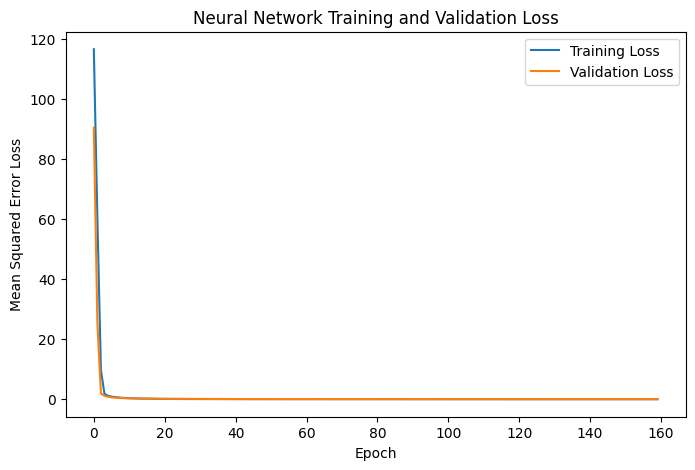

In [13]:
# Plot training and validation loss curves

display(Markdown("### Neural Network Training and Validation Loss"))
display(Markdown(f"Date: {todays_date}")) 
display(Markdown(f"Student ID: {student_id}"))

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Neural Network Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error Loss")
plt.legend()
plt.show()

## Neural Network Loss Curve Interpretation

The neural network training and validation loss curve shows that the model learned very quickly during the first few epochs. Both the training loss and validation loss dropped sharply at the beginning of training, which indicates that the model rapidly improved from its initial predictions.

After the early decrease, both curves leveled off and remained close together. This suggests that the model reached a stable learning point and that additional epochs did not produce major improvements. Since the training and validation loss curves stayed close to each other, there is not strong visual evidence of severe overfitting. If the model were overfitting, the training loss would continue decreasing while the validation loss increased.

The curve also suggests that early stopping was useful because the model stopped improving significantly after the initial learning period. However, even though the neural network learned useful patterns, the model comparison showed that Linear Regression still performed better overall.

It is also important to note that the loss curve is based on the log-transformed SalePrice values. Therefore, the mean squared error shown in the loss curve is not measured directly in dollars. The final MAE and RMSE values are more useful for interpreting prediction error in dollar terms.


### Baseline Linear Regression: Actual vs. Predicted SalePrice

Date: 2026-06-13

Student ID: Jerbra1624

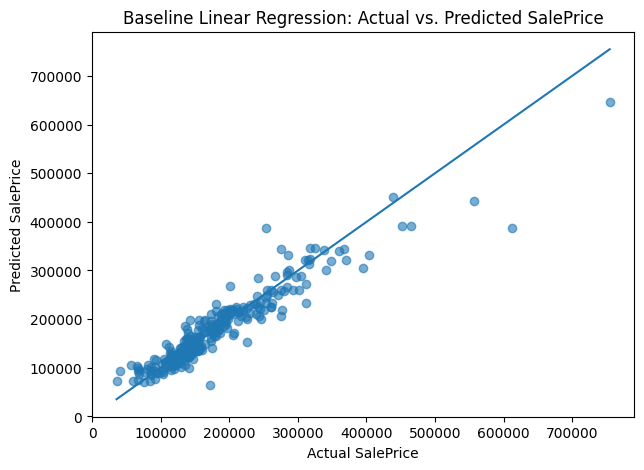

### Actual vs predicted plot for neural network

Date: 2026-06-13

Student ID: Jerbra1624

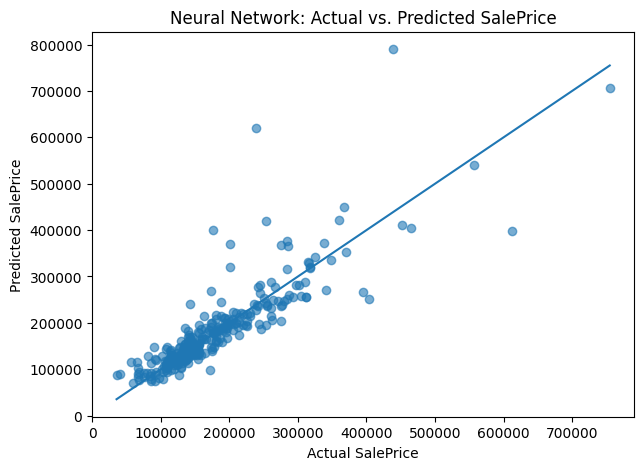

In [14]:
display(Markdown("### Baseline Linear Regression: Actual vs. Predicted SalePrice"))
display(Markdown(f"Date: {todays_date}")) 
display(Markdown(f"Student ID: {student_id}"))

# Convert true and predicted values back to dollar scale

actual_prices = np.expm1(y_test_log)
baseline_pred_prices = np.expm1(baseline_predictions_log)
nn_pred_prices = np.expm1(nn_predictions_log)

# Prevent negative predictions
baseline_pred_prices = np.maximum(baseline_pred_prices, 0)
nn_pred_prices = np.maximum(nn_pred_prices, 0)

# Actual vs predicted plot for baseline model
plt.figure(figsize=(7, 5))
plt.scatter(actual_prices, baseline_pred_prices, alpha=0.6)
plt.plot([actual_prices.min(), actual_prices.max()], [actual_prices.min(), actual_prices.max()])
plt.title("Baseline Linear Regression: Actual vs. Predicted SalePrice")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.show()

display(Markdown("### Actual vs predicted plot for neural network"))
display(Markdown(f"Date: {todays_date}")) 
display(Markdown(f"Student ID: {student_id}"))

# Actual vs predicted plot for neural network
plt.figure(figsize=(7, 5))
plt.scatter(actual_prices, nn_pred_prices, alpha=0.6)
plt.plot([actual_prices.min(), actual_prices.max()], [actual_prices.min(), actual_prices.max()])
plt.title("Neural Network: Actual vs. Predicted SalePrice")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.show()

### Neural Network Residual Plot

Date: 2026-06-13

Student ID: Jerbra1624

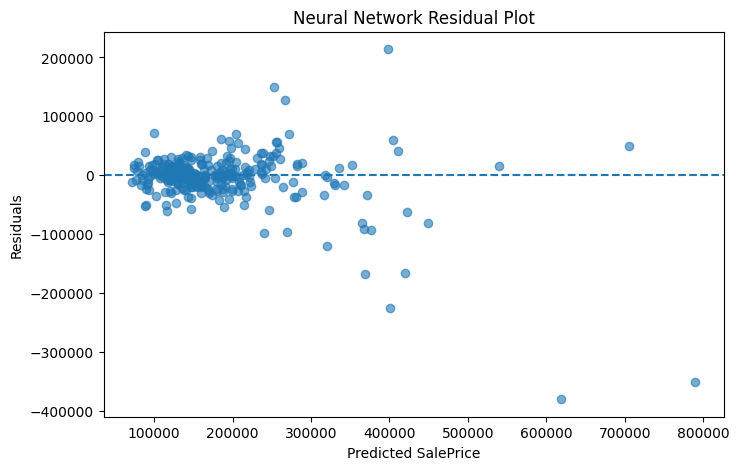

In [15]:
display(Markdown("### Neural Network Residual Plot"))
display(Markdown(f"Date: {todays_date}")) 
display(Markdown(f"Student ID: {student_id}"))

# Calculate neural network residuals
nn_residuals = actual_prices - nn_pred_prices

plt.figure(figsize=(8, 5))
plt.scatter(nn_pred_prices, nn_residuals, alpha=0.6)
plt.axhline(y=0, linestyle="--")
plt.title("Neural Network Residual Plot")
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residuals")
plt.show()

## Final Model Summary

This notebook implemented two predictive models for the House Prices dataset: a Baseline Linear Regression model and a Neural Network Regression model. Since SalePrice is a continuous numerical variable, both models were evaluated as regression models using MAE, MSE, RMSE, and R-squared. The Kaggle training dataset was split into training and testing subsets because the separate Kaggle test dataset does not include SalePrice.

The Baseline Linear Regression model was the strongest overall model. It produced an MAE of approximately 18,609 dollars, an RMSE of approximately 29,571 dollars, and an R-squared value of approximately 0.886. This means the model explained about 88.6% of the variation in SalePrice and made relatively accurate predictions for many homes in the test set.

The adjusted Neural Network Regression model also performed reasonably well, but it did not outperform the baseline model. The neural network produced an MAE of approximately 24,700 dollars, an RMSE of approximately 46,307 dollars, and an R-squared value of approximately 0.720. This means the neural network explained about 72.0% of the variation in SalePrice. While this was a meaningful improvement compared to the earlier neural network attempt, its errors were still larger than the Linear Regression model’s errors.

The visualizations support these results. The Linear Regression actual-versus-predicted plot shows predictions that are more closely aligned with the diagonal reference line. This means the baseline model’s predicted prices were generally closer to the actual sale prices. The neural network actual-versus-predicted plot shows a similar overall pattern, but with more spread around the reference line. This indicates that the neural network captured some useful relationships but had less consistent prediction accuracy.

The neural network residual plot shows that many predictions were fairly close for lower and mid-range homes, but some higher-priced homes had larger errors. This suggests that the neural network had more difficulty predicting unusual or expensive homes. These larger residuals may be related to outliers, limited training data, or housing features that were not fully captured by the selected variables.

Overall, the Linear Regression model is the better model for this stage of the project. The neural network improved after simplifying the architecture, but it still did not perform as well as the baseline model. This result shows that more complex models do not automatically produce better results, especially with smaller tabular datasets. Future work could focus on additional tuning, outlier treatment, feature engineering, or comparison with other machine learning models.


In [16]:
# Create dashboard dataset from the full housing data
dashboard_data = data.copy()

# Export housing data with engineered features
dashboard_data.to_csv("housing_dashboard_data.csv", index=False)

# Create model prediction dataset using the test set
model_predictions_dashboard = pd.DataFrame({
    "Actual_SalePrice": actual_prices,
    "Baseline_Predicted_SalePrice": baseline_pred_prices,
    "Neural_Network_Predicted_SalePrice": nn_pred_prices
})

# Add residuals
model_predictions_dashboard["Baseline_Residual"] = (
    model_predictions_dashboard["Actual_SalePrice"] -
    model_predictions_dashboard["Baseline_Predicted_SalePrice"]
)

model_predictions_dashboard["Neural_Network_Residual"] = (
    model_predictions_dashboard["Actual_SalePrice"] -
    model_predictions_dashboard["Neural_Network_Predicted_SalePrice"]
)

# Export prediction data
model_predictions_dashboard.to_csv("model_predictions_dashboard.csv", index=False)

# Create model metrics dataset
model_metrics_dashboard = pd.DataFrame({
    "Model": ["Baseline Linear Regression", "Neural Network Regression"],
    "MAE": [18608.596745, 24699.573791],
    "MSE": [8.744248e08, 2.144349e09],
    "RMSE": [29570.674044, 46307.112569],
    "R_squared": [0.885999, 0.720436]
})

model_metrics_dashboard.to_csv("model_metrics_dashboard.csv", index=False)

print("Dashboard CSV files created successfully.")

Dashboard CSV files created successfully.


In [17]:
from pathlib import Path

output_folder = Path("/Users/jaybee718/Desktop/SDC486-Data Analytics-Lab/house-prices-advanced-regression-techniques")

dashboard_data.to_csv(output_folder / "housing_dashboard_data.csv", index=False)
model_predictions_dashboard.to_csv(output_folder / "model_predictions_dashboard.csv", index=False)
model_metrics_dashboard.to_csv(output_folder / "model_metrics_dashboard.csv", index=False)

print("Files saved to:", output_folder)

Files saved to: /Users/jaybee718/Desktop/SDC486-Data Analytics-Lab/house-prices-advanced-regression-techniques


# Scenario Analysis



This section uses the trained Neural Network Regression model to evaluate three housing scenarios. Each scenario changes selected input features while keeping the trained model and preprocessing pipeline unchanged. The scenario predictions will be compared with the original neural network predictions to determine how changes in location, renovation history, and property size affect predicted sale price.

In [18]:
# Check which important variables are available for scenario analysis

objects_to_check = [
    "data",
    "df",
    "X",
    "y",
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "preprocessor",
    "X_train_processed",
    "X_test_processed",
    "nn_model",
    "nn_predictions",
    "nn_pred",
    "y_pred_nn"
]

print("Scenario analysis variable check:\n")

for object_name in objects_to_check:
    if object_name in globals():
        current_object = globals()[object_name]

        try:
            object_shape = current_object.shape
        except AttributeError:
            object_shape = "No shape available"

        print(f"{object_name}: FOUND | Shape: {object_shape}")
    else:
        print(f"{object_name}: Not found")

Scenario analysis variable check:

data: FOUND | Shape: (1460, 87)
df: Not found
X: FOUND | Shape: (1460, 24)
y: FOUND | Shape: (1460,)
X_train: FOUND | Shape: (1168, 24)
X_test: FOUND | Shape: (292, 24)
y_train: Not found
y_test: Not found
preprocessor: FOUND | Shape: No shape available
X_train_processed: FOUND | Shape: (1168, 88)
X_test_processed: FOUND | Shape: (292, 88)
nn_model: FOUND | Shape: No shape available
nn_predictions: Not found
nn_pred: Not found
y_pred_nn: Not found


In [19]:
# Preview the test-set structure

print("X_test type:", type(X_test))
print("X_test shape:", X_test.shape)

display(X_test.head())

X_test type: <class 'pandas.DataFrame'>
X_test shape: (292, 24)


,Neighborhood,Condition1,Condition2,OverallQual,GrLivArea,GarageArea,TotalBsmtSF,FullBath,LotArea,YearBuilt,...,LotFrontage,MasVnrArea,GarageAgeAtSale,HasGarage,HasBasement,BsmtQual,GarageType,FireplaceQu,Fence,PoolQC
892,Sawyer,Norm,Norm,6,1068,264,1059,1,8414,1963,...,70.0,0.0,43.0,Has Garage,Has Basement,TA,Attchd,None,MnPrv,None
1105,NoRidge,Norm,Norm,8,2622,712,1463,2,12256,1994,...,98.0,362.0,16.0,Has Garage,Has Basement,Ex,Attchd,TA,None,None
413,OldTown,Artery,Norm,5,1028,360,1008,1,8960,1927,...,56.0,0.0,83.0,Has Garage,Has Basement,TA,Detchd,Gd,None,None
522,BrkSide,Feedr,Norm,6,1664,420,1004,2,5000,1947,...,50.0,0.0,56.0,Has Garage,Has Basement,TA,Detchd,Gd,None,None
1036,Timber,Norm,Norm,9,1620,912,1620,2,12898,2007,...,89.0,70.0,1.0,Has Garage,Has Basement,Ex,Attchd,Ex,None,None


In [20]:
# Check whether the main scenario features are available

scenario_features = [
    "Neighborhood",
    "GrLivArea",
    "LotArea",
    "GarageArea",
    "TotalBsmtSF",
    "YearBuilt",
    "YearRemodAdd",
    "YrSold",
    "HomeAgeAtSale",
    "YearsSinceRemodel",
    "IsRemodeled"
]

print("Available scenario features:\n")

for feature in scenario_features:
    if feature in X_test.columns:
        print(f"{feature}: FOUND")
    else:
        print(f"{feature}: Not found")

Available scenario features:

Neighborhood: FOUND
GrLivArea: FOUND
LotArea: FOUND
GarageArea: FOUND
TotalBsmtSF: FOUND
YearBuilt: FOUND
YearRemodAdd: FOUND
YrSold: Not found
HomeAgeAtSale: FOUND
YearsSinceRemodel: FOUND
IsRemodeled: FOUND


## Baseline Neural Network Prediction Check

Before creating the scenario datasets, the existing neural network output and target transformation are examined. This ensures that all baseline and scenario predictions are converted back to sale-price dollars using the same method.

In [21]:
# Locate variables related to targets, predictions, scaling, and transformations

search_terms = [
    "y_train",
    "y_test",
    "target",
    "pred",
    "scaler",
    "log",
    "saleprice"
]

matching_variables = []

for variable_name in sorted(globals()):
    variable_name_lower = variable_name.lower()

    if any(term in variable_name_lower for term in search_terms):
        matching_variables.append(variable_name)

print("Possible target, prediction, or scaling variables:\n")

for variable_name in matching_variables:
    current_object = globals()[variable_name]

    try:
        object_shape = current_object.shape
    except AttributeError:
        object_shape = "No shape available"

    print(
        f"{variable_name}: "
        f"{type(current_object).__name__} | "
        f"Shape: {object_shape}"
    )

Possible target, prediction, or scaling variables:

StandardScaler: type | Shape: No shape available
baseline_pred_prices: ndarray | Shape: (292,)
baseline_predictions_log: ndarray | Shape: (292,)
model_predictions_dashboard: DataFrame | Shape: (292, 5)
nn_pred_prices: ndarray | Shape: (292,)
nn_predictions_log: ndarray | Shape: (292,)
y_log: Series | Shape: (1460,)
y_test_log: Series | Shape: (292,)
y_train_log: Series | Shape: (1168,)


In [22]:
# Generate raw neural network output for the original test set

raw_nn_output = nn_model.predict(
    X_test_processed,
    verbose=0
).reshape(-1)

print("Raw neural network output summary:")
print(f"Number of predictions: {len(raw_nn_output)}")
print(f"Minimum: {raw_nn_output.min():,.4f}")
print(f"Maximum: {raw_nn_output.max():,.4f}")
print(f"Mean: {raw_nn_output.mean():,.4f}")
print(f"Median: {np.median(raw_nn_output):,.4f}")

print("\nOriginal y variable summary:")
print(f"Minimum: {y.min():,.4f}")
print(f"Maximum: {y.max():,.4f}")
print(f"Mean: {y.mean():,.4f}")
print(f"Median: {y.median():,.4f}")

Raw neural network output summary:
Number of predictions: 292
Minimum: 11.1752
Maximum: 13.5799
Mean: 12.0223
Median: 11.9595

Original y variable summary:
Minimum: 34,900.0000
Maximum: 755,000.0000
Mean: 180,921.1959
Median: 163,000.0000


In [23]:
# Confirm that the model output is converted back to dollars with np.expm1

converted_test_predictions = np.expm1(raw_nn_output)

difference = np.abs(
    converted_test_predictions - nn_pred_prices
)

print("Maximum difference:", difference.max())
print("Average difference:", difference.mean())

print("\nSample converted predictions:")
print(converted_test_predictions[:5])

print("\nExisting nn_pred_prices:")
print(nn_pred_prices[:5])

Maximum difference: 0.0
Average difference: 0.0

Sample converted predictions:
[140752.84 341434.9  113642.16 187159.86 329212.28]

Existing nn_pred_prices:
[140752.84 341434.9  113642.16 187159.86 329212.28]


## Scenario 1: Premium Neighborhood

This scenario evaluates how location may affect the Neural Network model’s predicted sale prices. Each home in the test dataset is reassigned to the NridgHt neighborhood while all other housing features remain unchanged.

NridgHt was selected because the exploratory analysis and Power BI dashboard showed that it had one of the highest median sale prices among the neighborhoods in the dataset. The purpose of this scenario is to isolate the effect of changing the neighborhood feature and compare the resulting predictions with the original Neural Network baseline predictions.

Assumption: The homes are treated as though they were located in NridgHt, but their size, quality, age, renovation status, and other characteristics remain unchanged.


In [24]:
# Store the original neural network predictions as the scenario baseline

baseline_nn_predictions = nn_pred_prices.copy()

print("Baseline prediction summary:")
print(f"Number of homes: {len(baseline_nn_predictions)}")
print(f"Average predicted price: {baseline_nn_predictions.mean():,.2f}")
print(f"Median predicted price: {np.median(baseline_nn_predictions):,.2f}")
print(f"Minimum predicted price: {baseline_nn_predictions.min():,.2f}")
print(f"Maximum predicted price: {baseline_nn_predictions.max():,.2f}")

Baseline prediction summary:
Number of homes: 292
Average predicted price: 182,760.77
Median predicted price: 156,298.16
Minimum predicted price: 71,336.85
Maximum predicted price: 790,095.44


In [25]:
# Create a copy of the original test data for Scenario 1

scenario1_data = X_test.copy()

print("Original neighborhood counts:")
print(scenario1_data["Neighborhood"].value_counts().head())

Original neighborhood counts:
Neighborhood
NAmes      44
CollgCr    35
OldTown    22
Somerst    17
Sawyer     16
Name: count, dtype: int64


In [26]:
# Assign all test homes to the premium NridgHt neighborhood

scenario1_data["Neighborhood"] = "NridgHt"

print("Scenario 1 neighborhood counts:")
print(scenario1_data["Neighborhood"].value_counts())

Scenario 1 neighborhood counts:
Neighborhood
NridgHt    292
Name: count, dtype: int64


In [27]:
# Apply the same fitted preprocessing pipeline used during model training

scenario1_processed = preprocessor.transform(scenario1_data)

print("Original processed test shape:", X_test_processed.shape)
print("Scenario 1 processed shape:", scenario1_processed.shape)

Original processed test shape: (292, 88)
Scenario 1 processed shape: (292, 88)


In [28]:
# Generate raw log predictions for Scenario 1

scenario1_predictions_log = nn_model.predict(
    scenario1_processed,
    verbose=0
).reshape(-1)

# Convert the log predictions back into sale-price dollars

scenario1_pred_prices = np.expm1(
    scenario1_predictions_log
)

print("Scenario 1 prediction summary:")
print(f"Average predicted price: {scenario1_pred_prices.mean():,.2f}")
print(f"Median predicted price: {np.median(scenario1_pred_prices):,.2f}")
print(f"Minimum predicted price: {scenario1_pred_prices.min():,.2f}")
print(f"Maximum predicted price: {scenario1_pred_prices.max():,.2f}")

Scenario 1 prediction summary:
Average predicted price: 187,159.23
Median predicted price: 166,436.84
Minimum predicted price: 71,085.23
Maximum predicted price: 875,387.94


In [29]:
# Compare Premium Neighborhood predictions with the baseline predictions

scenario1_change = (
    scenario1_pred_prices - baseline_nn_predictions
)

scenario1_percent_change = (
    scenario1_change / baseline_nn_predictions
) * 100

scenario1_comparison = pd.DataFrame({
    "HomeIndex": X_test.index,
    "Scenario": "Premium Neighborhood",
    "OriginalNeighborhood": X_test["Neighborhood"].values,
    "ScenarioNeighborhood": scenario1_data["Neighborhood"].values,
    "BaselinePrediction": baseline_nn_predictions,
    "ScenarioPrediction": scenario1_pred_prices,
    "PredictionChange": scenario1_change,
    "PercentChange": scenario1_percent_change
})

display(scenario1_comparison.head())

,HomeIndex,Scenario,OriginalNeighborhood,ScenarioNeighborhood,BaselinePrediction,ScenarioPrediction,PredictionChange,PercentChange
0,892,Premium Neighborhood,Sawyer,NridgHt,140752.843750,143088.328125,2335.484375,1.659280
1,1105,Premium Neighborhood,NoRidge,NridgHt,341434.906250,305129.031250,-36305.875000,-10.633323
2,413,Premium Neighborhood,OldTown,NridgHt,113642.156250,110375.695312,-3266.460938,-2.874339
3,522,Premium Neighborhood,BrkSide,NridgHt,187159.859375,153941.140625,-33218.718750,-17.748848
4,1036,Premium Neighborhood,Timber,NridgHt,329212.281250,429208.250000,99995.968750,30.374313


In [30]:
# Summarize the Premium Neighborhood scenario

scenario1_summary = pd.DataFrame({
    "Scenario": ["Premium Neighborhood"],
    "BaselineAveragePrediction": [
        baseline_nn_predictions.mean()
    ],
    "ScenarioAveragePrediction": [
        scenario1_pred_prices.mean()
    ],
    "AverageDollarChange": [
        scenario1_change.mean()
    ],
    "AveragePercentChange": [
        scenario1_percent_change.mean()
    ],
    "HomesWithHigherPrediction": [
        (scenario1_change > 0).sum()
    ],
    "HomesWithLowerPrediction": [
        (scenario1_change < 0).sum()
    ]
})

display(scenario1_summary.round(2))

,Scenario,BaselineAveragePrediction,ScenarioAveragePrediction,AverageDollarChange,AveragePercentChange,HomesWithHigherPrediction,HomesWithLowerPrediction
0,Premium Neighborhood,182760.765625,187159.234375,4398.459961,4.33,164,112


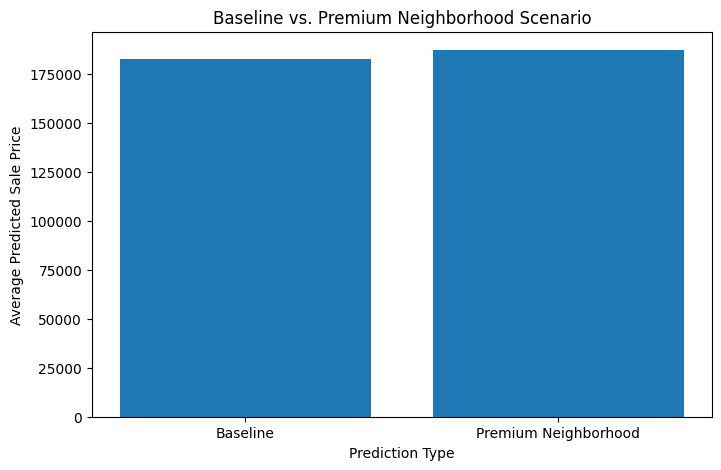

In [31]:
# Visualize the average baseline and Scenario 1 predictions

scenario1_chart_data = pd.DataFrame({
    "Prediction Type": [
        "Baseline",
        "Premium Neighborhood"
    ],
    "Average Predicted Sale Price": [
        baseline_nn_predictions.mean(),
        scenario1_pred_prices.mean()
    ]
})

plt.figure(figsize=(8, 5))
plt.bar(
    scenario1_chart_data["Prediction Type"],
    scenario1_chart_data["Average Predicted Sale Price"]
)

plt.title("Baseline vs. Premium Neighborhood Scenario")
plt.xlabel("Prediction Type")
plt.ylabel("Average Predicted Sale Price")
plt.ticklabel_format(
    style="plain",
    axis="y"
)
plt.show()

In [32]:
# Print the main Scenario 1 findings

average_baseline = baseline_nn_predictions.mean()
average_scenario1 = scenario1_pred_prices.mean()
average_change = scenario1_change.mean()
average_percent = scenario1_percent_change.mean()

print("Scenario 1 Findings")
print("-------------------")
print(f"Baseline average prediction: {average_baseline:,.2f}")
print(f"Scenario average prediction: {average_scenario1:,.2f}")
print(f"Average dollar change: {average_change:,.2f}")
print(f"Average percentage change: {average_percent:,.2f}%")
print(
    "Homes with increased predictions:",
    (scenario1_change > 0).sum()
)
print(
    "Homes with decreased predictions:",
    (scenario1_change < 0).sum()
)

Scenario 1 Findings
-------------------
Baseline average prediction: 182,760.77
Scenario average prediction: 187,159.23
Average dollar change: 4,398.46
Average percentage change: 4.33%
Homes with increased predictions: 164
Homes with decreased predictions: 112


### Scenario 1 Findings: Premium Neighborhood

The Premium Neighborhood scenario increased the Neural Network model’s average predicted sale price from $182,760.77 to $187,159.23. This represents an average dollar increase of approximately $4,398.46 and an overall increase of approximately 2.41% in the average predicted price.

Of the 292 homes evaluated, 164 received higher predicted prices and 112 received lower predicted prices after being reassigned to the NridgHt neighborhood. A small number of homes experienced little or no meaningful change. These mixed results suggest that the model does not apply the same neighborhood adjustment to every property. Instead, it evaluates neighborhood together with other features such as living area, overall quality, age, basement area, and garage area.

Overall, the scenario supports the finding that location contributes to predicted home value. However, the relatively moderate change also indicates that neighborhood is only one of several factors used by the Neural Network model when estimating SalePrice.


## Scenario 2: Recent Renovation

This scenario evaluates how a recent renovation may affect the Neural Network model’s predicted sale prices. Each home in the test dataset is treated as though it was remodeled during the same year it was sold.

The scenario changes YearRemodAdd, YearsSinceRemodel, and IsRemodeled while keeping the home’s neighborhood, living area, overall quality, age, and other characteristics unchanged. The purpose is to isolate the model’s response to renovation-related features.

Assumption: Every property receives a recent renovation, but the renovation does not change the home’s size, number of rooms, overall quality rating, or other structural characteristics.

In [34]:
# Create a copy of the original test data for Scenario 2

scenario2_data = X_test.copy()

print("Scenario 2 copy created.")
print("Shape:", scenario2_data.shape)

Scenario 2 copy created.
Shape: (292, 24)


In [35]:
# Reconstruct the sale year from existing remodel information

estimated_sale_year = (
    scenario2_data["YearRemodAdd"]
    + scenario2_data["YearsSinceRemodel"]
)

print("Estimated sale year summary:")
print(estimated_sale_year.describe())

Estimated sale year summary:
count     292.000000
mean     2007.804795
std         1.351941
min      2006.000000
25%      2007.000000
50%      2008.000000
75%      2009.000000
max      2010.000000
dtype: float64


In [36]:
# Apply the Recent Renovation scenario

scenario2_data["YearRemodAdd"] = estimated_sale_year
scenario2_data["YearsSinceRemodel"] = 0
scenario2_data["IsRemodeled"] = "Remodeled"

print("Scenario 2 remodel status:")
print(scenario2_data["IsRemodeled"].value_counts())

print("\nYearsSinceRemodel values:")
print(scenario2_data["YearsSinceRemodel"].value_counts().head())

print("\nUpdated YearRemodAdd summary:")
print(scenario2_data["YearRemodAdd"].describe())

Scenario 2 remodel status:
IsRemodeled
Remodeled    292
Name: count, dtype: int64

YearsSinceRemodel values:
YearsSinceRemodel
0    292
Name: count, dtype: int64

Updated YearRemodAdd summary:
count     292.000000
mean     2007.804795
std         1.351941
min      2006.000000
25%      2007.000000
50%      2008.000000
75%      2009.000000
max      2010.000000
Name: YearRemodAdd, dtype: float64


In [37]:
# Confirm that X_test remains unchanged

print("Original X_test remodel values:")
print(X_test["IsRemodeled"].value_counts())

print("\nScenario 2 remodel values:")
print(scenario2_data["IsRemodeled"].value_counts())

Original X_test remodel values:
IsRemodeled
Not Remodeled    163
Remodeled        129
Name: count, dtype: int64

Scenario 2 remodel values:
IsRemodeled
Remodeled    292
Name: count, dtype: int64


In [38]:
# Apply the fitted preprocessing pipeline to Scenario 2

scenario2_processed = preprocessor.transform(scenario2_data)

print("Original processed test shape:", X_test_processed.shape)
print("Scenario 2 processed shape:", scenario2_processed.shape)

Original processed test shape: (292, 88)
Scenario 2 processed shape: (292, 88)


In [39]:
# Generate Neural Network predictions for Scenario 2

scenario2_predictions_log = nn_model.predict(
    scenario2_processed,
    verbose=0
).reshape(-1)

# Convert log predictions back to sale-price dollars

scenario2_pred_prices = np.expm1(
    scenario2_predictions_log
)

print("Scenario 2 prediction summary:")
print(f"Average predicted price: {scenario2_pred_prices.mean():,.2f}")
print(f"Median predicted price: {np.median(scenario2_pred_prices):,.2f}")
print(f"Minimum predicted price: {scenario2_pred_prices.min():,.2f}")
print(f"Maximum predicted price: {scenario2_pred_prices.max():,.2f}")

Scenario 2 prediction summary:
Average predicted price: 193,456.12
Median predicted price: 171,235.11
Minimum predicted price: 75,184.35
Maximum predicted price: 719,827.12


In [40]:
# Compare Recent Renovation predictions with baseline predictions

scenario2_change = (
    scenario2_pred_prices - baseline_nn_predictions
)

scenario2_percent_change = (
    scenario2_change / baseline_nn_predictions
) * 100

scenario2_comparison = pd.DataFrame({
    "HomeIndex": X_test.index,
    "Scenario": "Recent Renovation",
    "OriginalYearRemodAdd": X_test["YearRemodAdd"].values,
    "ScenarioYearRemodAdd": scenario2_data["YearRemodAdd"].values,
    "OriginalYearsSinceRemodel": X_test["YearsSinceRemodel"].values,
    "ScenarioYearsSinceRemodel": scenario2_data["YearsSinceRemodel"].values,
    "OriginalRemodelStatus": X_test["IsRemodeled"].values,
    "ScenarioRemodelStatus": scenario2_data["IsRemodeled"].values,
    "BaselinePrediction": baseline_nn_predictions,
    "ScenarioPrediction": scenario2_pred_prices,
    "PredictionChange": scenario2_change,
    "PercentChange": scenario2_percent_change
})

display(scenario2_comparison.head())

,HomeIndex,Scenario,OriginalYearRemodAdd,ScenarioYearRemodAdd,OriginalYearsSinceRemodel,ScenarioYearsSinceRemodel,OriginalRemodelStatus,ScenarioRemodelStatus,BaselinePrediction,ScenarioPrediction,PredictionChange,PercentChange
0,892,Recent Renovation,2003,2006,3,0,Remodeled,Remodeled,140752.843750,145782.687500,5029.843750,3.573529
1,1105,Recent Renovation,1995,2010,15,0,Remodeled,Remodeled,341434.906250,329811.562500,-11623.343750,-3.404263
2,413,Recent Renovation,1950,2010,60,0,Remodeled,Remodeled,113642.156250,108928.523438,-4713.632812,-4.147786
3,522,Recent Renovation,1950,2006,56,0,Remodeled,Remodeled,187159.859375,192152.890625,4993.031250,2.667789
4,1036,Recent Renovation,2008,2009,1,0,Remodeled,Remodeled,329212.281250,332323.187500,3110.906250,0.944955


In [41]:
# Create a summary of Scenario 2 results

scenario2_baseline_average = baseline_nn_predictions.mean()
scenario2_average = scenario2_pred_prices.mean()

scenario2_average_dollar_change = (
    scenario2_average - scenario2_baseline_average
)

scenario2_overall_percent_change = (
    scenario2_average_dollar_change
    / scenario2_baseline_average
) * 100

scenario2_higher = np.sum(scenario2_change > 0)
scenario2_lower = np.sum(scenario2_change < 0)

scenario2_unchanged = np.sum(
    np.isclose(scenario2_change, 0, atol=0.01)
)

scenario2_summary = pd.DataFrame({
    "Scenario": ["Recent Renovation"],
    "BaselineAveragePrediction": [
        scenario2_baseline_average
    ],
    "ScenarioAveragePrediction": [
        scenario2_average
    ],
    "AverageDollarChange": [
        scenario2_average_dollar_change
    ],
    "OverallAveragePercentChange": [
        scenario2_overall_percent_change
    ],
    "MeanIndividualPercentChange": [
        scenario2_percent_change.mean()
    ],
    "HomesWithHigherPrediction": [
        scenario2_higher
    ],
    "HomesWithLowerPrediction": [
        scenario2_lower
    ],
    "HomesWithNoMeaningfulChange": [
        scenario2_unchanged
    ]
})

display(scenario2_summary.round(2))

,Scenario,BaselineAveragePrediction,ScenarioAveragePrediction,AverageDollarChange,OverallAveragePercentChange,MeanIndividualPercentChange,HomesWithHigherPrediction,HomesWithLowerPrediction,HomesWithNoMeaningfulChange
0,Recent Renovation,182760.765625,193456.125,10695.360352,5.85,7.95,221,59,12


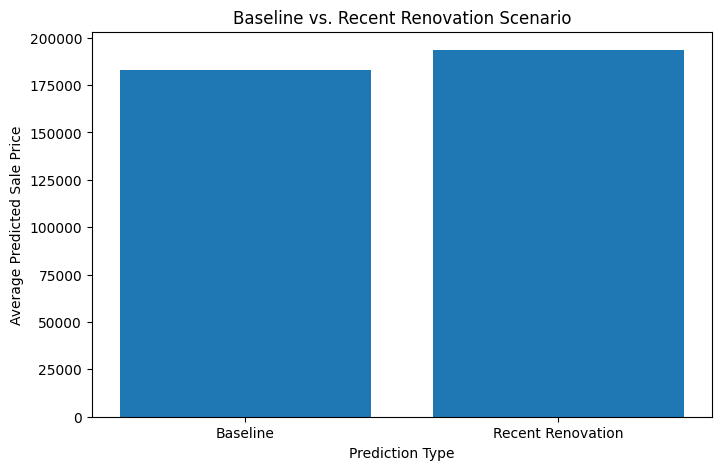

In [42]:
# Visualize baseline and Recent Renovation average predictions

scenario2_chart_data = pd.DataFrame({
    "Prediction Type": [
        "Baseline",
        "Recent Renovation"
    ],
    "Average Predicted Sale Price": [
        baseline_nn_predictions.mean(),
        scenario2_pred_prices.mean()
    ]
})

plt.figure(figsize=(8, 5))

plt.bar(
    scenario2_chart_data["Prediction Type"],
    scenario2_chart_data["Average Predicted Sale Price"]
)

plt.title("Baseline vs. Recent Renovation Scenario")
plt.xlabel("Prediction Type")
plt.ylabel("Average Predicted Sale Price")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

In [43]:
# Print the primary Scenario 2 findings

print("Scenario 2 Findings")
print("-------------------")

print(
    f"Baseline average prediction: "
    f"{scenario2_baseline_average:,.2f}"
)

print(
    f"Scenario average prediction: "
    f"{scenario2_average:,.2f}"
)

print(
    f"Average dollar change: "
    f"{scenario2_average_dollar_change:,.2f}"
)

print(
    f"Overall average percentage change: "
    f"{scenario2_overall_percent_change:,.2f}%"
)

print(
    "Homes with increased predictions:",
    scenario2_higher
)

print(
    "Homes with decreased predictions:",
    scenario2_lower
)

print(
    "Homes with no meaningful change:",
    scenario2_unchanged
)

Scenario 2 Findings
-------------------
Baseline average prediction: 182,760.77
Scenario average prediction: 193,456.12
Average dollar change: 10,695.36
Overall average percentage change: 5.85%
Homes with increased predictions: 221
Homes with decreased predictions: 59
Homes with no meaningful change: 12


### Scenario 2 Findings: Recent Renovation

The Recent Renovation scenario increased the Neural Network model’s average predicted sale price from $182,760.77 to $193,456.12. This represents an average increase of approximately $10,695.36, or 5.85%, in the overall average predicted price.

Of the 292 homes evaluated, 221 received higher predicted sale prices, 59 received lower predictions, and 12 experienced no meaningful change. The large number of increased predictions suggests that the model generally associates recent remodeling with stronger home values.

The results were not identical for every property because the Neural Network evaluates renovation-related features together with other characteristics, including home age, overall quality, living area, neighborhood, basement area, and garage area. Therefore, marking a home as recently remodeled does not automatically create the same increase for every property.

Compared with the Premium Neighborhood scenario, the Recent Renovation scenario produced a larger increase in the overall average predicted sale price. This suggests that renovation recency had a stronger effect on the model’s predictions than the neighborhood change tested in Scenario 1.

These findings should be interpreted as model-based sensitivity results rather than proof that every renovation would produce the predicted financial return. The scenario changes renovation indicators but does not account for renovation cost, type, quality, or scope.


## Scenario 3: Expanded Property

This scenario evaluates how increases in property size affect the Neural Network model’s predicted sale prices. Each home in the test dataset is modified to represent a larger property by increasing above-ground living area and lot area by 20%, while garage area and total basement area are increased by 10%.

The scenario is relevant to the project’s analysis of property-size outliers and model sensitivity. Larger homes generally showed stronger sale prices during exploratory analysis, but unusually large properties may also fall outside the range commonly represented in the training data.

Assumption: The property expansion does not change the home’s neighborhood, overall quality, age, renovation status, number of bathrooms, or other characteristics. Therefore, the scenario isolates the model’s response to selected size-related features.

The resulting predictions should be interpreted as model-based sensitivity estimates rather than guaranteed increases in market value.


In [44]:
# Create a copy of the original test data for Scenario 3

scenario3_data = X_test.copy()

print("Scenario 3 copy created.")
print("Shape:", scenario3_data.shape)

Scenario 3 copy created.
Shape: (292, 24)


In [45]:
# Define the percentage increases for Scenario 3

scenario3_adjustments = {
    "GrLivArea": 1.20,
    "LotArea": 1.20,
    "GarageArea": 1.10,
    "TotalBsmtSF": 1.10
}

print("Scenario 3 adjustments:")

for feature, multiplier in scenario3_adjustments.items():
    percentage_increase = (multiplier - 1) * 100
    print(f"{feature}: {percentage_increase:.0f}% increase")

Scenario 3 adjustments:
GrLivArea: 20% increase
LotArea: 20% increase
GarageArea: 10% increase
TotalBsmtSF: 10% increase


In [46]:
# Apply the property expansion changes

for feature, multiplier in scenario3_adjustments.items():
    scenario3_data[feature] = (
        scenario3_data[feature] * multiplier
    ).round(0)

print("Scenario 3 property-size changes applied.")

Scenario 3 property-size changes applied.


In [47]:
# Compare original and Scenario 3 feature statistics

scenario3_feature_review = []

for feature, multiplier in scenario3_adjustments.items():
    scenario3_feature_review.append({
        "Feature": feature,
        "IncreasePercent": (multiplier - 1) * 100,
        "OriginalAverage": X_test[feature].mean(),
        "ScenarioAverage": scenario3_data[feature].mean(),
        "OriginalMaximum": X_test[feature].max(),
        "ScenarioMaximum": scenario3_data[feature].max()
    })

scenario3_feature_review = pd.DataFrame(
    scenario3_feature_review
)

display(scenario3_feature_review.round(2))

,Feature,IncreasePercent,OriginalAverage,ScenarioAverage,OriginalMaximum,ScenarioMaximum
0,GrLivArea,20.0,1467.71,1761.27,4316,5179.0
1,LotArea,20.0,9825.57,11790.70,70761,84913.0
2,GarageArea,10.0,459.80,505.81,1390,1529.0
3,TotalBsmtSF,10.0,1040.06,1144.10,3206,3527.0


In [48]:
# Check whether Scenario 3 creates values beyond the training-data range

scenario3_range_check = []

for feature in scenario3_adjustments:
    training_maximum = X_train[feature].max()
    scenario_maximum = scenario3_data[feature].max()

    homes_above_training_max = (
        scenario3_data[feature] > training_maximum
    ).sum()

    scenario3_range_check.append({
        "Feature": feature,
        "TrainingMaximum": training_maximum,
        "ScenarioMaximum": scenario_maximum,
        "HomesAboveTrainingMaximum": homes_above_training_max
    })

scenario3_range_check = pd.DataFrame(
    scenario3_range_check
)

display(scenario3_range_check)

,Feature,TrainingMaximum,ScenarioMaximum,HomesAboveTrainingMaximum
0,GrLivArea,5642,5179.0,0
1,LotArea,215245,84913.0,0
2,GarageArea,1418,1529.0,1
3,TotalBsmtSF,6110,3527.0,0


In [49]:
# Confirm that only the Scenario 3 copy was modified

comparison_check = pd.DataFrame({
    "OriginalGrLivArea": X_test["GrLivArea"].head(),
    "ScenarioGrLivArea": scenario3_data["GrLivArea"].head(),
    "OriginalLotArea": X_test["LotArea"].head(),
    "ScenarioLotArea": scenario3_data["LotArea"].head()
})

display(comparison_check)

,OriginalGrLivArea,ScenarioGrLivArea,OriginalLotArea,ScenarioLotArea
892,1068,1282.0,8414,10097.0
1105,2622,3146.0,12256,14707.0
413,1028,1234.0,8960,10752.0
522,1664,1997.0,5000,6000.0
1036,1620,1944.0,12898,15478.0


In [50]:
# Apply the existing fitted preprocessor to Scenario 3

scenario3_processed = preprocessor.transform(
    scenario3_data
)

print("Original processed test shape:", X_test_processed.shape)
print("Scenario 3 processed shape:", scenario3_processed.shape)

Original processed test shape: (292, 88)
Scenario 3 processed shape: (292, 88)


In [51]:
# Generate Neural Network predictions for Scenario 3

scenario3_predictions_log = nn_model.predict(
    scenario3_processed,
    verbose=0
).reshape(-1)

# Convert predictions from log values back to dollars

scenario3_pred_prices = np.expm1(
    scenario3_predictions_log
)

print("Scenario 3 prediction summary:")
print(
    f"Average predicted price: "
    f"{scenario3_pred_prices.mean():,.2f}"
)
print(
    f"Median predicted price: "
    f"{np.median(scenario3_pred_prices):,.2f}"
)
print(
    f"Minimum predicted price: "
    f"{scenario3_pred_prices.min():,.2f}"
)
print(
    f"Maximum predicted price: "
    f"{scenario3_pred_prices.max():,.2f}"
)

Scenario 3 prediction summary:
Average predicted price: 203,334.67
Median predicted price: 172,815.16
Minimum predicted price: 76,401.27
Maximum predicted price: 1,140,845.25


In [52]:
# Compare Expanded Property predictions with baseline predictions

scenario3_change = (
    scenario3_pred_prices - baseline_nn_predictions
)

scenario3_percent_change = (
    scenario3_change / baseline_nn_predictions
) * 100

scenario3_comparison = pd.DataFrame({
    "HomeIndex": X_test.index,
    "Scenario": "Expanded Property",
    "OriginalGrLivArea": X_test["GrLivArea"].values,
    "ScenarioGrLivArea": scenario3_data["GrLivArea"].values,
    "OriginalLotArea": X_test["LotArea"].values,
    "ScenarioLotArea": scenario3_data["LotArea"].values,
    "OriginalGarageArea": X_test["GarageArea"].values,
    "ScenarioGarageArea": scenario3_data["GarageArea"].values,
    "OriginalTotalBsmtSF": X_test["TotalBsmtSF"].values,
    "ScenarioTotalBsmtSF": scenario3_data["TotalBsmtSF"].values,
    "BaselinePrediction": baseline_nn_predictions,
    "ScenarioPrediction": scenario3_pred_prices,
    "PredictionChange": scenario3_change,
    "PercentChange": scenario3_percent_change
})

display(scenario3_comparison.head())

,HomeIndex,Scenario,OriginalGrLivArea,ScenarioGrLivArea,OriginalLotArea,ScenarioLotArea,OriginalGarageArea,ScenarioGarageArea,OriginalTotalBsmtSF,ScenarioTotalBsmtSF,BaselinePrediction,ScenarioPrediction,PredictionChange,PercentChange
0,892,Expanded Property,1068,1282.0,8414,10097.0,264,290.0,1059,1165.0,140752.843750,152272.203125,11519.359375,8.184104
1,1105,Expanded Property,2622,3146.0,12256,14707.0,712,783.0,1463,1609.0,341434.906250,380622.687500,39187.781250,11.477380
2,413,Expanded Property,1028,1234.0,8960,10752.0,360,396.0,1008,1109.0,113642.156250,116215.148438,2572.992188,2.264118
3,522,Expanded Property,1664,1997.0,5000,6000.0,420,462.0,1004,1104.0,187159.859375,222154.187500,34994.328125,18.697561
4,1036,Expanded Property,1620,1944.0,12898,15478.0,912,1003.0,1620,1782.0,329212.281250,382127.718750,52915.437500,16.073349


In [53]:
# Create a summary of Scenario 3 results

scenario3_baseline_average = baseline_nn_predictions.mean()
scenario3_average = scenario3_pred_prices.mean()

scenario3_average_dollar_change = (
    scenario3_average - scenario3_baseline_average
)

scenario3_overall_percent_change = (
    scenario3_average_dollar_change
    / scenario3_baseline_average
) * 100

scenario3_higher = np.sum(scenario3_change > 0)
scenario3_lower = np.sum(scenario3_change < 0)

scenario3_unchanged = np.sum(
    np.isclose(scenario3_change, 0, atol=0.01)
)

scenario3_summary = pd.DataFrame({
    "Scenario": ["Expanded Property"],
    "BaselineAveragePrediction": [
        scenario3_baseline_average
    ],
    "ScenarioAveragePrediction": [
        scenario3_average
    ],
    "AverageDollarChange": [
        scenario3_average_dollar_change
    ],
    "OverallAveragePercentChange": [
        scenario3_overall_percent_change
    ],
    "MeanIndividualPercentChange": [
        scenario3_percent_change.mean()
    ],
    "HomesWithHigherPrediction": [
        scenario3_higher
    ],
    "HomesWithLowerPrediction": [
        scenario3_lower
    ],
    "HomesWithNoMeaningfulChange": [
        scenario3_unchanged
    ]
})

display(scenario3_summary.round(2))

,Scenario,BaselineAveragePrediction,ScenarioAveragePrediction,AverageDollarChange,OverallAveragePercentChange,MeanIndividualPercentChange,HomesWithHigherPrediction,HomesWithLowerPrediction,HomesWithNoMeaningfulChange
0,Expanded Property,182760.765625,203334.6875,20573.910156,11.26,10.53,282,10,0


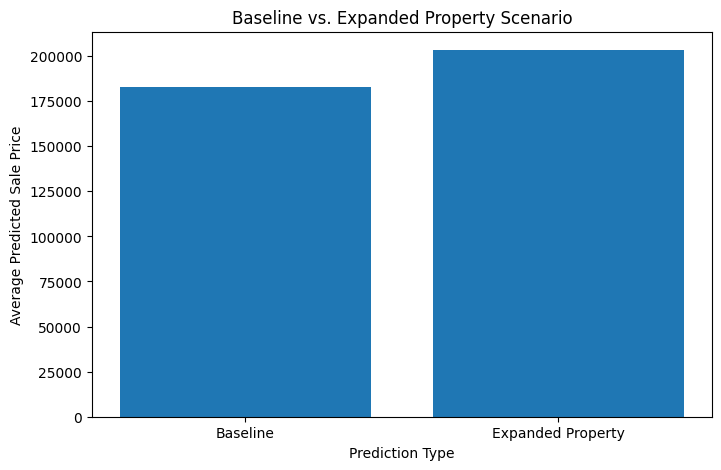

In [54]:
# Compare average baseline and Expanded Property predictions

scenario3_chart_data = pd.DataFrame({
    "Prediction Type": [
        "Baseline",
        "Expanded Property"
    ],
    "Average Predicted Sale Price": [
        baseline_nn_predictions.mean(),
        scenario3_pred_prices.mean()
    ]
})

plt.figure(figsize=(8, 5))

plt.bar(
    scenario3_chart_data["Prediction Type"],
    scenario3_chart_data["Average Predicted Sale Price"]
)

plt.title("Baseline vs. Expanded Property Scenario")
plt.xlabel("Prediction Type")
plt.ylabel("Average Predicted Sale Price")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

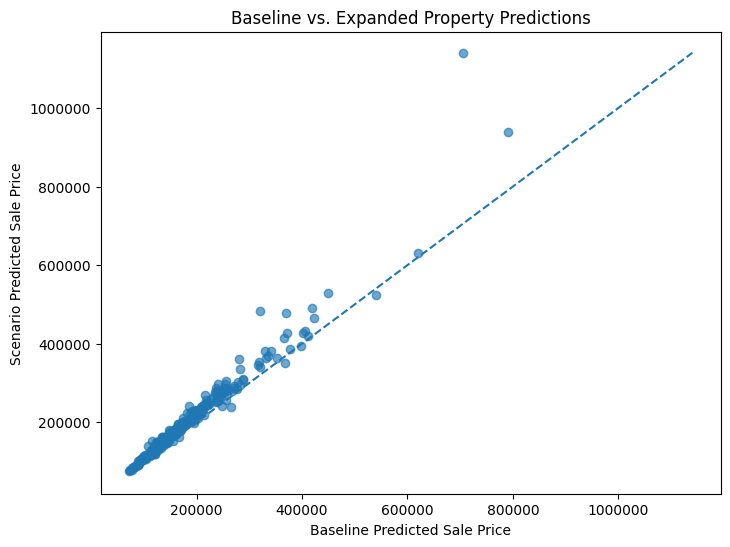

In [55]:
# Compare each baseline prediction with its Scenario 3 prediction

plt.figure(figsize=(8, 6))

plt.scatter(
    baseline_nn_predictions,
    scenario3_pred_prices,
    alpha=0.65
)

minimum_value = min(
    baseline_nn_predictions.min(),
    scenario3_pred_prices.min()
)

maximum_value = max(
    baseline_nn_predictions.max(),
    scenario3_pred_prices.max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)

plt.title(
    "Baseline vs. Expanded Property Predictions"
)
plt.xlabel("Baseline Predicted Sale Price")
plt.ylabel("Scenario Predicted Sale Price")
plt.ticklabel_format(style="plain", axis="both")
plt.show()

In [56]:
# Print the primary Scenario 3 findings

print("Scenario 3 Findings")
print("-------------------")

print(
    f"Baseline average prediction: "
    f"{scenario3_baseline_average:,.2f}"
)

print(
    f"Scenario average prediction: "
    f"{scenario3_average:,.2f}"
)

print(
    f"Average dollar change: "
    f"{scenario3_average_dollar_change:,.2f}"
)

print(
    f"Overall average percentage change: "
    f"{scenario3_overall_percent_change:,.2f}%"
)

print(
    "Homes with increased predictions:",
    scenario3_higher
)

print(
    "Homes with decreased predictions:",
    scenario3_lower
)

print(
    "Homes with no meaningful change:",
    scenario3_unchanged
)

Scenario 3 Findings
-------------------
Baseline average prediction: 182,760.77
Scenario average prediction: 203,334.67
Average dollar change: 20,573.91
Overall average percentage change: 11.26%
Homes with increased predictions: 282
Homes with decreased predictions: 10
Homes with no meaningful change: 0


### Scenario 3 Findings: Expanded Property

The Expanded Property scenario increased the Neural Network model’s average predicted sale price from $182,760.77 to $203,334.67. This represents an average dollar increase of approximately $20,573.91 and an overall increase of 11.26% in the average predicted sale price.

Of the 292 homes evaluated, 282 received higher predictions and 10 received lower predictions. No homes experienced no meaningful change. These results suggest that the Neural Network model generally associates larger living areas, lots, garages, and basements with higher home values.

The Expanded Property scenario produced the largest average increase among the three scenarios. Its 11.26% increase was greater than the 5.85% increase from the Recent Renovation scenario and the 2.41% increase from the Premium Neighborhood scenario. Based on the model’s predictions, the selected property-size features had the strongest combined effect on predicted SalePrice.

The training-range analysis showed that the modified values for above-ground living area, lot area, and basement area remained within the ranges represented in the training data. Only one home had a garage area that exceeded the training maximum. Therefore, most scenario predictions were generated within ranges the model had previously encountered, although the prediction for the property exceeding the garage-area range should be interpreted cautiously.

The 10 decreased predictions demonstrate that the Neural Network does not apply a fixed price increase when property size changes. Instead, it evaluates interactions between size, neighborhood, overall quality, age, renovation status, and other housing characteristics.

These results represent model sensitivity rather than guaranteed market outcomes. The scenario does not account for construction costs, permitting requirements, layout quality, buyer preferences, or whether an expansion would provide a positive financial return.


# Combined Scenario Results and Power BI Export

This section combines the Premium Neighborhood, Recent Renovation, and Expanded Property scenario results into standardized tables. The detailed table contains one row per home for each scenario, while the summary table contains one row per scenario. Both tables will be exported as CSV files for use in Power BI.

In [57]:
# Confirm that all required scenario variables are available

required_variables = [
    "X_test",
    "y_test_log",
    "baseline_nn_predictions",
    "scenario1_data",
    "scenario1_pred_prices",
    "scenario2_data",
    "scenario2_pred_prices",
    "scenario3_data",
    "scenario3_pred_prices"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise NameError(
        "The following required variables are missing: "
        + ", ".join(missing_variables)
    )

print("All required scenario variables were found.")

All required scenario variables were found.


In [58]:
# Convert the actual test target values back to sale-price dollars

actual_test_prices = np.expm1(
    y_test_log.loc[X_test.index].to_numpy()
)

print("Actual test price summary:")
print(f"Number of homes: {len(actual_test_prices)}")
print(f"Average actual price: {actual_test_prices.mean():,.2f}")
print(f"Minimum actual price: {actual_test_prices.min():,.2f}")
print(f"Maximum actual price: {actual_test_prices.max():,.2f}")

Actual test price summary:
Number of homes: 292
Average actual price: 178,839.81
Minimum actual price: 35,311.00
Maximum actual price: 755,000.00


In [59]:
# Create a standardized row-level table for each scenario

def build_scenario_detail(
    scenario_name,
    scenario_order,
    scenario_data,
    scenario_predictions
):
    baseline_predictions = np.asarray(
        baseline_nn_predictions
    ).reshape(-1)

    scenario_predictions = np.asarray(
        scenario_predictions
    ).reshape(-1)

    prediction_change = (
        scenario_predictions - baseline_predictions
    )

    percent_change = np.where(
        baseline_predictions != 0,
        prediction_change / baseline_predictions * 100,
        np.nan
    )

    prediction_direction = np.where(
        np.isclose(prediction_change, 0, atol=0.01),
        "No Meaningful Change",
        np.where(
            prediction_change > 0,
            "Higher",
            "Lower"
        )
    )

    scenario_key = scenario_name.replace(" ", "_")

    detail_table = pd.DataFrame({
        "ScenarioPredictionID": [
            f"{scenario_key}_{number:03d}"
            for number in range(1, len(X_test) + 1)
        ],
        "PredictionID": np.arange(1, len(X_test) + 1),
        "HomeIndex": X_test.index.to_numpy(),
        "ScenarioOrder": scenario_order,
        "Scenario": scenario_name,
        "ActualSalePrice": actual_test_prices,
        "BaselinePrediction": baseline_predictions,
        "ScenarioPrediction": scenario_predictions,
        "PredictionChange": prediction_change,
        "PercentChange": percent_change,
        "PredictionDirection": prediction_direction,

        # Original feature values
        "OriginalNeighborhood":
            X_test["Neighborhood"].astype(str).values,
        "OriginalOverallQual":
            X_test["OverallQual"].values,
        "OriginalGrLivArea":
            X_test["GrLivArea"].values,
        "OriginalLotArea":
            X_test["LotArea"].values,
        "OriginalGarageArea":
            X_test["GarageArea"].values,
        "OriginalTotalBsmtSF":
            X_test["TotalBsmtSF"].values,
        "OriginalHomeAgeAtSale":
            X_test["HomeAgeAtSale"].values,
        "OriginalYearsSinceRemodel":
            X_test["YearsSinceRemodel"].values,
        "OriginalIsRemodeled":
            X_test["IsRemodeled"].astype(str).values,

        # Scenario feature values
        "ScenarioNeighborhood":
            scenario_data["Neighborhood"].astype(str).values,
        "ScenarioOverallQual":
            scenario_data["OverallQual"].values,
        "ScenarioGrLivArea":
            scenario_data["GrLivArea"].values,
        "ScenarioLotArea":
            scenario_data["LotArea"].values,
        "ScenarioGarageArea":
            scenario_data["GarageArea"].values,
        "ScenarioTotalBsmtSF":
            scenario_data["TotalBsmtSF"].values,
        "ScenarioHomeAgeAtSale":
            scenario_data["HomeAgeAtSale"].values,
        "ScenarioYearsSinceRemodel":
            scenario_data["YearsSinceRemodel"].values,
        "ScenarioIsRemodeled":
            scenario_data["IsRemodeled"].astype(str).values
    })

    return detail_table

In [60]:
# Build one standardized detail table for each scenario

scenario1_detail = build_scenario_detail(
    scenario_name="Premium Neighborhood",
    scenario_order=1,
    scenario_data=scenario1_data,
    scenario_predictions=scenario1_pred_prices
)

scenario2_detail = build_scenario_detail(
    scenario_name="Recent Renovation",
    scenario_order=2,
    scenario_data=scenario2_data,
    scenario_predictions=scenario2_pred_prices
)

scenario3_detail = build_scenario_detail(
    scenario_name="Expanded Property",
    scenario_order=3,
    scenario_data=scenario3_data,
    scenario_predictions=scenario3_pred_prices
)

# Combine all three scenarios

scenario_analysis_details = pd.concat(
    [
        scenario1_detail,
        scenario2_detail,
        scenario3_detail
    ],
    ignore_index=True
)

print(
    "Combined detail-table shape:",
    scenario_analysis_details.shape
)

display(scenario_analysis_details.head())

Combined detail-table shape: (876, 29)


,ScenarioPredictionID,PredictionID,HomeIndex,ScenarioOrder,Scenario,ActualSalePrice,BaselinePrediction,ScenarioPrediction,PredictionChange,PercentChange,...,OriginalIsRemodeled,ScenarioNeighborhood,ScenarioOverallQual,ScenarioGrLivArea,ScenarioLotArea,ScenarioGarageArea,ScenarioTotalBsmtSF,ScenarioHomeAgeAtSale,ScenarioYearsSinceRemodel,ScenarioIsRemodeled
0,Premium_Neighborhood_001,1,892,1,Premium Neighborhood,154500.0,140752.843750,143088.328125,2335.484375,1.659280,...,Remodeled,NridgHt,6,1068.0,8414.0,264.0,1059.0,43,3,Remodeled
1,Premium_Neighborhood_002,2,1105,1,Premium Neighborhood,325000.0,341434.906250,305129.031250,-36305.875000,-10.633323,...,Remodeled,NridgHt,8,2622.0,12256.0,712.0,1463.0,16,15,Remodeled
2,Premium_Neighborhood_003,3,413,1,Premium Neighborhood,115000.0,113642.156250,110375.695312,-3266.460938,-2.874339,...,Remodeled,NridgHt,5,1028.0,8960.0,360.0,1008.0,83,60,Remodeled
3,Premium_Neighborhood_004,4,522,1,Premium Neighborhood,159000.0,187159.859375,153941.140625,-33218.718750,-17.748848,...,Remodeled,NridgHt,6,1664.0,5000.0,420.0,1004.0,59,56,Remodeled
4,Premium_Neighborhood_005,5,1036,1,Premium Neighborhood,315500.0,329212.281250,429208.250000,99995.968750,30.374313,...,Remodeled,NridgHt,9,1620.0,12898.0,912.0,1620.0,2,1,Remodeled


In [61]:
# Create one summary row for each scenario

scenario_summary_records = []

scenario_sets = [
    (
        "Premium Neighborhood",
        1,
        scenario1_pred_prices
    ),
    (
        "Recent Renovation",
        2,
        scenario2_pred_prices
    ),
    (
        "Expanded Property",
        3,
        scenario3_pred_prices
    )
]

for scenario_name, scenario_order, scenario_predictions in scenario_sets:

    scenario_predictions = np.asarray(
        scenario_predictions
    ).reshape(-1)

    baseline_average = baseline_nn_predictions.mean()
    scenario_average = scenario_predictions.mean()

    dollar_change = scenario_average - baseline_average

    overall_percent_change = (
        dollar_change / baseline_average
    ) * 100

    individual_changes = (
        scenario_predictions - baseline_nn_predictions
    )

    individual_percent_changes = (
        individual_changes / baseline_nn_predictions
    ) * 100

    higher_count = np.sum(individual_changes > 0)
    lower_count = np.sum(individual_changes < 0)

    unchanged_count = np.sum(
        np.isclose(
            individual_changes,
            0,
            atol=0.01
        )
    )

    scenario_summary_records.append({
        "ScenarioOrder": scenario_order,
        "Scenario": scenario_name,
        "TotalHomes": len(X_test),
        "AverageActualSalePrice":
            actual_test_prices.mean(),
        "BaselineAveragePrediction":
            baseline_average,
        "ScenarioAveragePrediction":
            scenario_average,
        "AverageDollarChange":
            dollar_change,
        "OverallAveragePercentChange":
            overall_percent_change,
        "MeanIndividualPercentChange":
            individual_percent_changes.mean(),
        "HomesWithHigherPrediction":
            higher_count,
        "HomesWithLowerPrediction":
            lower_count,
        "HomesWithNoMeaningfulChange":
            unchanged_count
    })

scenario_analysis_summary = pd.DataFrame(
    scenario_summary_records
)

# Rank scenarios from greatest to smallest modeled impact

scenario_analysis_summary["ImpactRank"] = (
    scenario_analysis_summary[
        "AverageDollarChange"
    ]
    .rank(
        method="dense",
        ascending=False
    )
    .astype(int)
)

scenario_analysis_summary = (
    scenario_analysis_summary
    .sort_values("ScenarioOrder")
    .reset_index(drop=True)
)

display(scenario_analysis_summary.round(2))

,ScenarioOrder,Scenario,TotalHomes,AverageActualSalePrice,BaselineAveragePrediction,ScenarioAveragePrediction,AverageDollarChange,OverallAveragePercentChange,MeanIndividualPercentChange,HomesWithHigherPrediction,HomesWithLowerPrediction,HomesWithNoMeaningfulChange,ImpactRank
0,1,Premium Neighborhood,292,178839.81,182760.765625,187159.234375,4398.470215,2.41,4.33,164,112,16,3
1,2,Recent Renovation,292,178839.81,182760.765625,193456.125000,10695.360352,5.85,7.95,221,59,12,2
2,3,Expanded Property,292,178839.81,182760.765625,203334.687500,20573.910156,11.26,10.53,282,10,0,1


In [62]:
# Validate the scenario-analysis tables before export

expected_detail_rows = len(X_test) * 3

assert len(scenario_analysis_details) == expected_detail_rows, (
    "The detail table does not contain the expected number of rows."
)

scenario_row_counts = (
    scenario_analysis_details
    .groupby("Scenario")
    .size()
)

assert (
    scenario_row_counts == len(X_test)
).all(), (
    "At least one scenario does not contain all test homes."
)

summary_count_check = (
    scenario_analysis_summary[
        [
            "HomesWithHigherPrediction",
            "HomesWithLowerPrediction",
            "HomesWithNoMeaningfulChange"
        ]
    ]
    .sum(axis=1)
)

assert (
    summary_count_check == len(X_test)
).all(), (
    "The higher, lower, and unchanged counts do not total 292."
)

key_columns = [
    "Scenario",
    "BaselinePrediction",
    "ScenarioPrediction",
    "PredictionChange",
    "PercentChange"
]

assert not scenario_analysis_details[
    key_columns
].isna().any().any(), (
    "Missing values were found in required detail columns."
)

print("Validation successful.")
print("\nRows per scenario:")
print(scenario_row_counts)

print(
    "\nTotal detail rows:",
    len(scenario_analysis_details)
)

print(
    "Total summary rows:",
    len(scenario_analysis_summary)
)

Validation successful.

Rows per scenario:
Scenario
Expanded Property       292
Premium Neighborhood    292
Recent Renovation       292
dtype: int64

Total detail rows: 876
Total summary rows: 3


In [63]:
# Export the final scenario-analysis files for Power BI

from pathlib import Path

output_folder = Path.cwd()

details_file = (
    output_folder
    / "scenario_analysis_details.csv"
)

summary_file = (
    output_folder
    / "scenario_analysis_summary.csv"
)

scenario_analysis_details.to_csv(
    details_file,
    index=False
)

scenario_analysis_summary.to_csv(
    summary_file,
    index=False
)

print("Scenario CSV files saved successfully.\n")

print("Details file:")
print(details_file.resolve())

print("\nSummary file:")
print(summary_file.resolve())

Scenario CSV files saved successfully.

Details file:
/Users/jaybee718/scenario_analysis_details.csv

Summary file:
/Users/jaybee718/scenario_analysis_summary.csv


In [64]:
# Confirm that both Power BI files were created

exported_files = [
    details_file,
    summary_file
]

for file_path in exported_files:
    print(f"File: {file_path.name}")
    print(f"Exists: {file_path.exists()}")

    if file_path.exists():
        print(
            f"File size: "
            f"{file_path.stat().st_size:,} bytes"
        )

    print("-" * 40)

File: scenario_analysis_details.csv
Exists: True
File size: 188,580 bytes
----------------------------------------
File: scenario_analysis_summary.csv
Exists: True
File size: 592 bytes
----------------------------------------
